#Daily Challenge: Pokemon Win Prediction Analysis

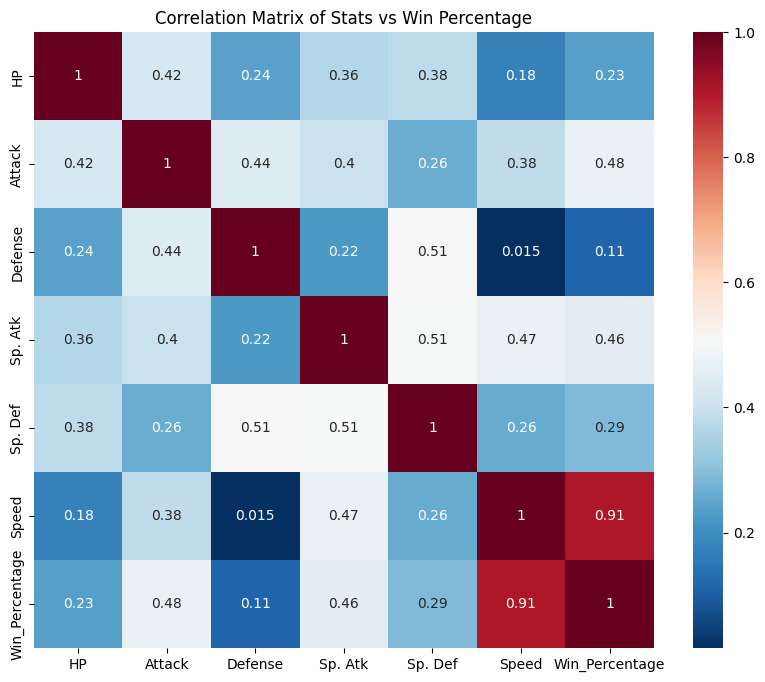

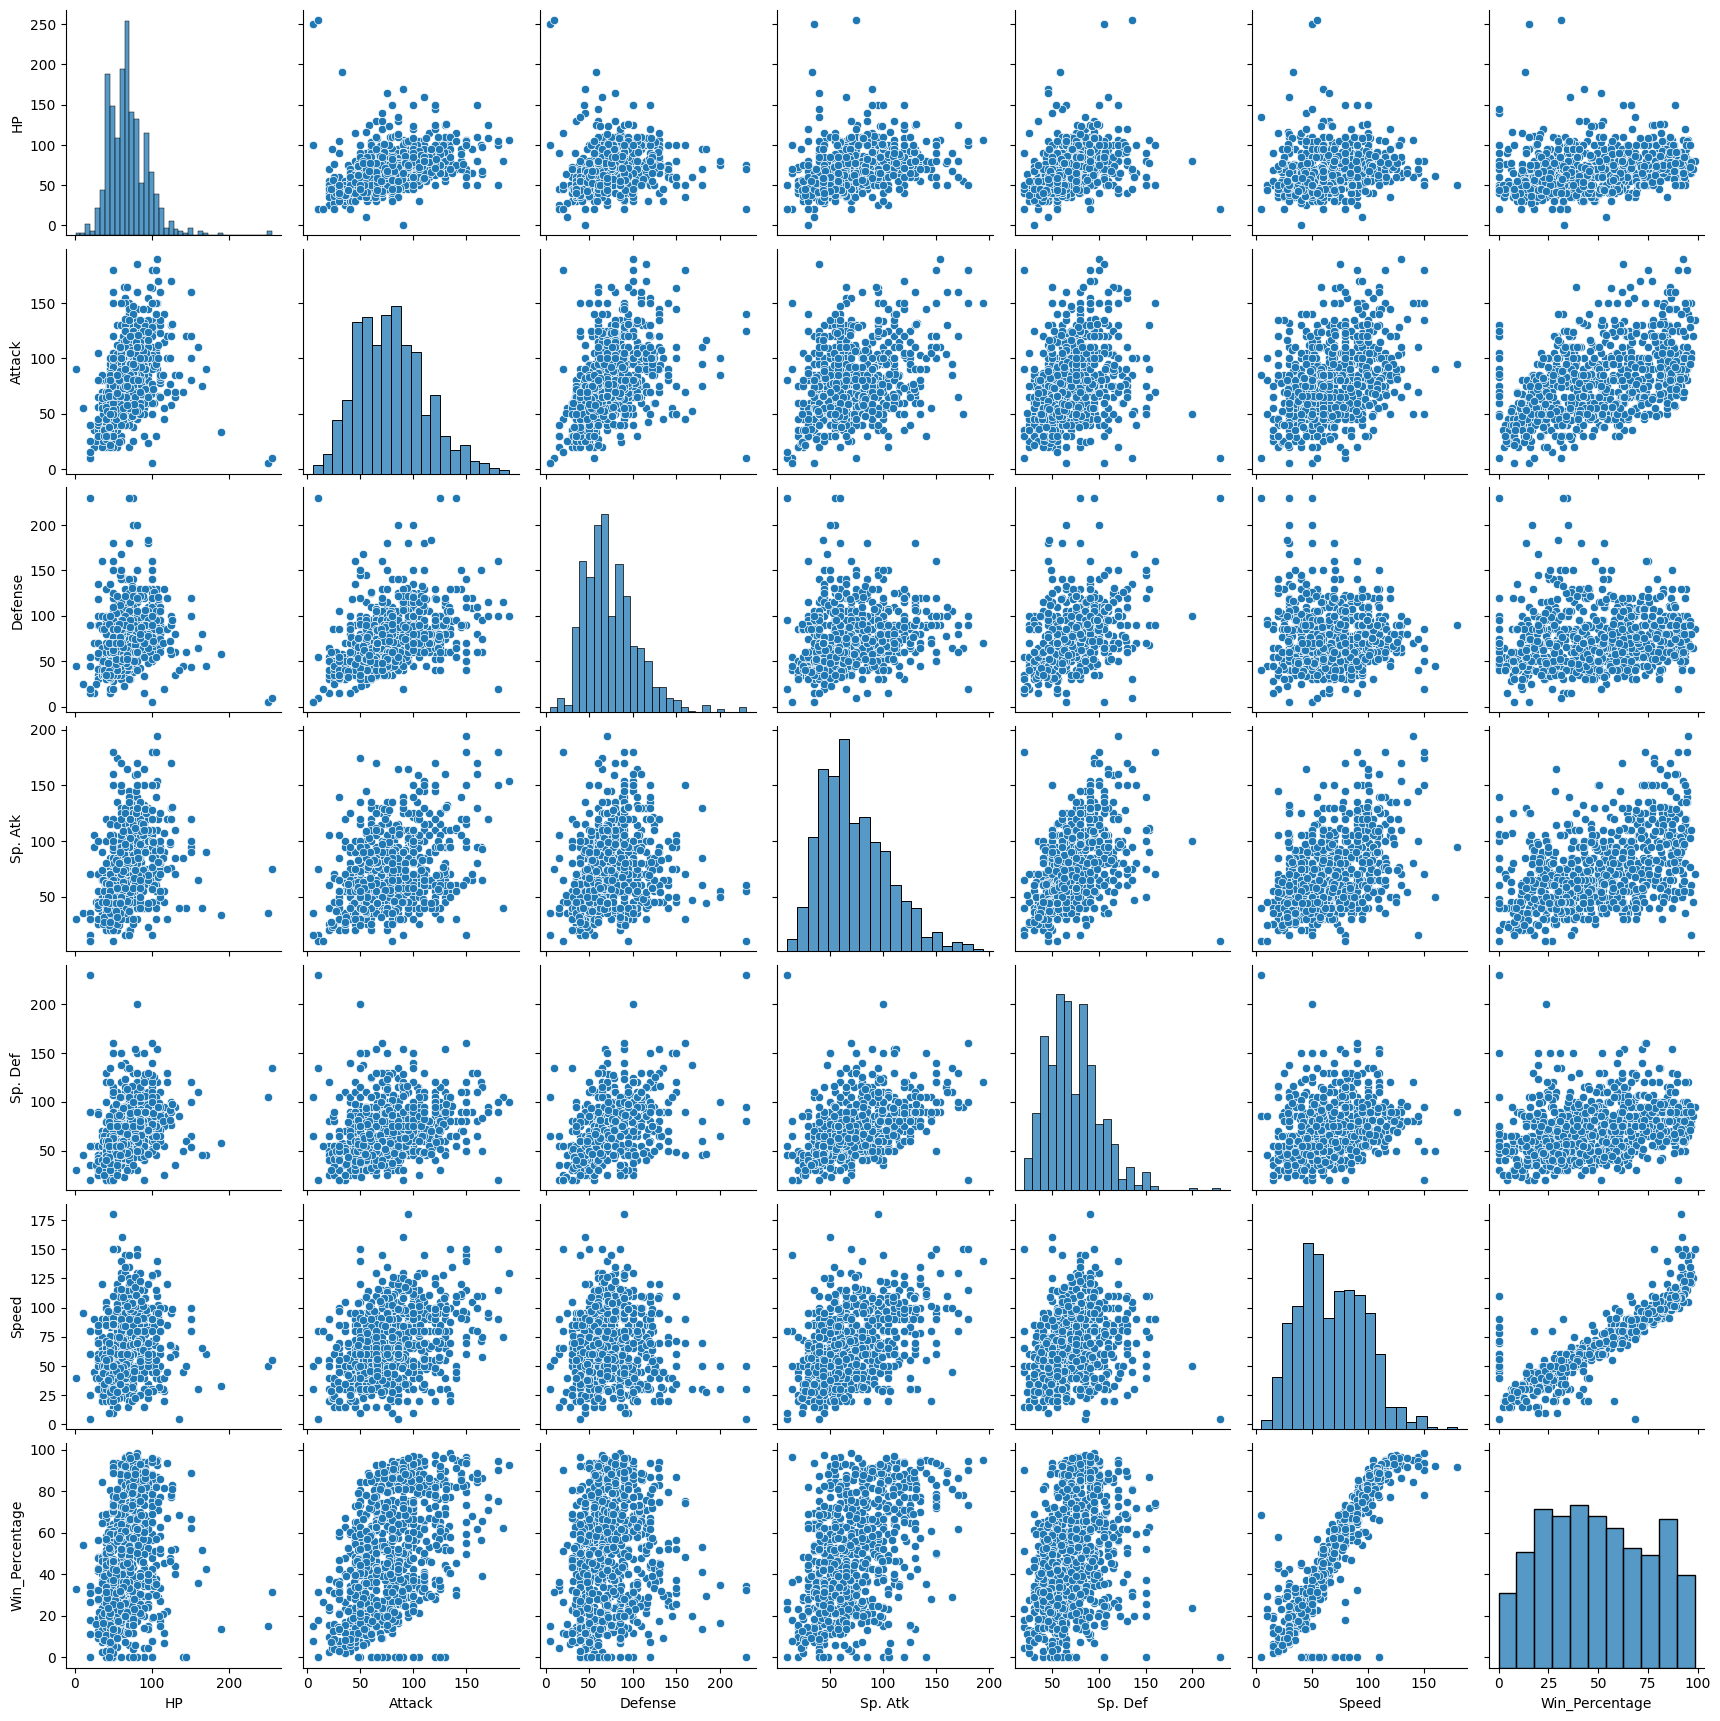

Top 10 Pokemon by Win Percentage:
                         Name  Win_Percentage   HP  Attack  Defense  Sp. Atk  \
154           Mega Aerodactyl       98.449612   80     135       85       70   
512                   Weavile       97.478992   70     120       65       45   
703    Tornadus Therian Forme       96.800000   79     100       80      110   
19              Mega Beedrill       96.638655   65     150       40       15   
153                Aerodactyl       96.453901   80     105       65       60   
476              Mega Lopunny       96.124031   65     136       94       54   
726                  Greninja       96.062992   72      95       67      103   
716  Meloetta Pirouette Forme       95.934959  100     128       90       77   
164             Mega Mewtwo Y       95.200000  106     150       70      194   
349             Mega Sharpedo       95.000000   70     140       70      110   

     Sp. Def  Speed  
154       95    150  
512       85    125  
703       90    121

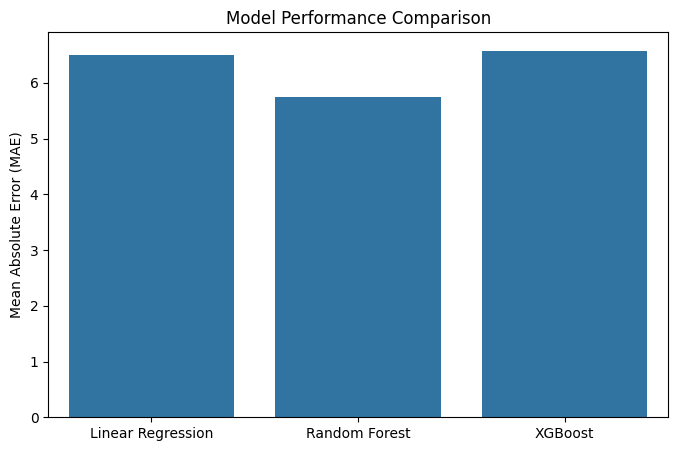

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# 1. Data Preparation
pokemon = pd.read_csv('/content/pokemon.csv')
combats = pd.read_csv('/content/combats.csv')

# Fix missing values
pokemon.loc[pokemon['#'] == 62, 'Name'] = 'Primeape'
pokemon['Type 2'] = pokemon['Type 2'].fillna('None')

# Calculate win percentage
total_fights = pd.concat([combats['First_pokemon'], combats['Second_pokemon']]).value_counts().sort_index()
wins = combats['Winner'].value_counts().sort_index()
win_stats = pd.DataFrame({'Wins': wins, 'Total_Fights': total_fights}).fillna(0)
win_stats['Win_Percentage'] = (win_stats['Wins'] / win_stats['Total_Fights']) * 100

# Merge with pokemon data
df = pokemon.merge(win_stats['Win_Percentage'], left_on='#', right_index=True, how='left').fillna(0)

# 2. Exploratory Analysis & Visualization
stats_cols = ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed', 'Win_Percentage']
corr_matrix = df[stats_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r')
plt.title('Correlation Matrix of Stats vs Win Percentage')
plt.show()

sns.pairplot(df[stats_cols])
plt.show()

print("Top 10 Pokemon by Win Percentage:")
print(df.nlargest(10, 'Win_Percentage')[['Name', 'Win_Percentage'] + stats_cols[:-1]])

# 3. Machine Learning
X = df[['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]
y = df['Win_Percentage']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    mae = mean_absolute_error(y_test, preds)
    results[name] = mae
    print(f"{name} MAE: {mae:.2f}")

# Compare performance
plt.figure(figsize=(8, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Model Performance Comparison')
plt.show()

## 4. Predictions on Test Data
Using the Random Forest model to predict win percentages for the provided `tests.csv` file.

In [2]:
test_combats = pd.read_csv('/content/tests.csv')

# Prepare features for the test set (averaging stats of the two pokemon in the matchup or predicting individual win probabilities)
# Since the model was trained on individual Pokemon win rates, we will predict the expected win rate for each Pokemon in the test pairs.

def get_stats(pokemon_id):
    return df.loc[df['#'] == pokemon_id, ['HP', 'Attack', 'Defense', 'Sp. Atk', 'Sp. Def', 'Speed']]

best_model = models['Random Forest']

results_list = []
for index, row in test_combats.iterrows():
    p1_stats = get_stats(row['First_pokemon'])
    p2_stats = get_stats(row['Second_pokemon'])

    p1_win_pred = best_model.predict(p1_stats)[0]
    p2_win_pred = best_model.predict(p2_stats)[0]

    results_list.append({
        'First_pokemon': row['First_pokemon'],
        'Second_pokemon': row['Second_pokemon'],
        'P1_Predicted_Win_Rate': p1_win_pred,
        'P2_Predicted_Win_Rate': p2_win_pred,
        'Predicted_Winner': row['First_pokemon'] if p1_win_pred > p2_win_pred else row['Second_pokemon']
    })

prediction_df = pd.DataFrame(results_list)
display(prediction_df.head(10))

,First_pokemon,Second_pokemon,P1_Predicted_Win_Rate,P2_Predicted_Win_Rate,Predicted_Winner
0,129,117,50.657601,14.187723,129
1,660,211,40.793000,21.903545,660
2,706,115,82.344064,66.865174,706
3,195,618,22.723242,16.715519,195
4,27,656,47.841314,50.134099,656
5,126,222,37.141615,22.040552,126
6,436,207,40.851331,12.027435,436
7,121,36,36.643757,34.118217,121
8,169,636,53.347681,21.919599,169
9,302,688,51.352095,41.678015,302
